# 01 - Prepare the snow response variables

**Manuscript:** *Snow Cover and Mean Snow Elevation Dynamics as Climate Change Indicators (KRI, 2000-2024)*
**Reviewer point addressed:** builds the tidy response dataset used by every later attribution notebook.

This notebook reads `data/raw/monthly_snow_2000_2024.xlsx` (sheets `S.Area`, `S.line`, `SDI`, `SCV`,
each stored as two side-by-side 72-month blocks) and produces:

| file | content |
|---|---|
| `data/snow_monthly.csv` | 144 rows, Oct-Mar 2000/01 - 2023/24, one row per month |
| `data/snow_seasonal.csv` | 24 rows, one per snow season, incl. melt-timing metrics |

**Seasonal definition.** A *snow season* runs October of year Y to March of year Y+1 and is
labelled by its ending year (season 2001 = Oct 2000 - Mar 2001). This matches the
`WinterGroup` convention in your existing R scripts.

**Extra metrics added here** (these also answer the reviewer's *"no discussion of snowmelt timing"*
comment at no extra data cost):

- `sca_peak_month` - month of maximum snow cover area
- `sca_centroid` - snow-cover centre of mass in months from 1 Oct (earlier = earlier melt)
- `melt_rate_feb_mar` - fractional SCA loss between February and March
- `sca_mean`, `sca_max`, `sle_mean`, `sle_min`, `sdi_mean`, `scv_mean`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- paths
# EDIT THIS if you move the notebook. On Windows use a raw string, e.g.
# ROOT = r"<repo>"
ROOT   = os.path.abspath(os.path.join(os.getcwd(), ".."))
XLSX   = os.path.join(ROOT, "data", "raw", "monthly_snow_2000_2024.xlsx")
OUTDIR = os.path.join(ROOT, "data", "derived")
FIGDIR = os.path.join(ROOT, "figures")
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

print("workbook exists:", os.path.exists(XLSX))
print("output folder  :", OUTDIR)

workbook exists: True
output folder  : <repo>/data


## 1. Read the four sheets and stack the two 12-season blocks

In [2]:
# sheet name -> (column label in block 1, tidy variable name)
SHEETS = {
    "S.Area": ("snow_area_km2",   "sca"),   # snow cover area, km2
    "S.line": ("snowline_mean_m", "sle"),   # mean snow(line) elevation, m  (MSE in the paper)
    "SDI":    ("SDI",             "sdi"),   # snow depletion / NDSI-based index
    "SCV":    ("SCV",             "scv"),   # snow cover variability
}

def read_block_sheet(xlsx, sheet, value_col):
    """Each sheet holds two blocks side by side: seasons 2000-10..2012-03 in
    columns (season, value) and 2012-10..2024-03 in (season.1, value.1)."""
    d = pd.read_excel(xlsx, sheet_name=sheet)
    b1 = d[["season", value_col]].rename(columns={"season": "ym", value_col: "value"})
    b2 = d[["season.1", value_col + ".1"]].rename(
        columns={"season.1": "ym", value_col + ".1": "value"})
    out = pd.concat([b1, b2], ignore_index=True).dropna(subset=["ym"])
    out["ym"] = out["ym"].astype(str).str.strip()
    return out

frames = {}
for sheet, (col, name) in SHEETS.items():
    frames[name] = read_block_sheet(XLSX, sheet, col).rename(columns={"value": name})
    print(f"{sheet:8s} -> {name:4s}  n={len(frames[name]):3d}  "
          f"missing={frames[name][name].isna().sum()}")

S.Area   -> sca   n=144  missing=0
S.line   -> sle   n=144  missing=17
SDI      -> sdi   n=144  missing=0
SCV      -> scv   n=144  missing=0


In [3]:
monthly = frames["sca"]
for name in ["sle", "sdi", "scv"]:
    monthly = monthly.merge(frames[name], on="ym", how="outer")

monthly["date"]  = pd.to_datetime(monthly["ym"] + "-01")
monthly          = monthly.sort_values("date").reset_index(drop=True)
monthly["year"]  = monthly["date"].dt.year
monthly["month"] = monthly["date"].dt.month

# snow season = Oct(Y)..Mar(Y+1), labelled by the ENDING year
monthly["season"] = np.where(monthly["month"] >= 10,
                             monthly["year"] + 1, monthly["year"])
monthly["season_label"] = (monthly["season"] - 1).astype(str) + "/" + \
                          monthly["season"].astype(str).str[-2:]
# month position within the season: Oct=1 ... Mar=6
monthly["season_month"] = np.where(monthly["month"] >= 10,
                                   monthly["month"] - 9, monthly["month"] + 3)

monthly = monthly[["date", "ym", "year", "month", "season", "season_label",
                   "season_month", "sca", "sle", "sdi", "scv"]]
print(monthly.shape)
monthly.head(8)

(144, 11)


,date,ym,year,month,season,season_label,season_month,sca,sle,sdi,scv
0,2000-10-01,2000-10,2000,10,2001,2000/01,1,1.682,3114.192,0.100,0.360
1,2000-11-01,2000-11,2000,11,2001,2000/01,2,101.711,2879.569,0.679,1.628
2,2000-12-01,2000-12,2000,12,2001,2000/01,3,4434.039,1831.175,8.373,8.807
3,2001-01-01,2001-01,2001,1,2001,2000/01,4,6367.939,1670.575,16.730,13.073
4,2001-02-01,2001-02,2001,2,2001,2000/01,5,5937.020,1716.945,13.804,9.868
5,2001-03-01,2001-03,2001,3,2001,2000/01,6,1539.069,2235.564,3.603,2.412
6,2001-10-01,2001-10,2001,10,2002,2001/02,1,0.000,NaN,0.063,0.258
7,2001-11-01,2001-11,2001,11,2002,2001/02,2,2039.249,2045.117,4.777,8.282


## 2. Seasonal aggregation + snowmelt-timing metrics

`sca_centroid` is the snow-cover centre of mass, in months after 1 October:

$$\mathrm{centroid} = \frac{\sum_m m \cdot SCA_m}{\sum_m SCA_m}$$

A **decreasing** centroid over time means the snow mass is concentrating earlier in the
season, i.e. earlier melt-out - exactly the diagnostic the reviewer asked for.

In [4]:
def season_metrics(g):
    g = g.sort_values("season_month")
    sca = g["sca"].astype(float)
    w   = sca.fillna(0.0)
    tot = w.sum()
    feb = g.loc[g["month"] == 2, "sca"]
    mar = g.loc[g["month"] == 3, "sca"]
    feb = float(feb.iloc[0]) if len(feb) else np.nan
    mar = float(mar.iloc[0]) if len(mar) else np.nan
    return pd.Series({
        "season_label":      g["season_label"].iloc[0],
        "sca_mean":          sca.mean(),
        "sca_max":           sca.max(),
        "sca_djfm":          g.loc[g["month"].isin([12, 1, 2, 3]), "sca"].mean(),
        "sca_peak_month":    g.loc[sca.idxmax(), "season_month"] if sca.notna().any() else np.nan,
        "sca_centroid":      float((g["season_month"] * w).sum() / tot) if tot > 0 else np.nan,
        "melt_rate_feb_mar": (feb - mar) / feb if (feb and feb > 0) else np.nan,
        "sle_mean":          g["sle"].mean(),
        "sle_min":           g["sle"].min(),
        "sle_djfm":          g.loc[g["month"].isin([12, 1, 2, 3]), "sle"].mean(),
        "sdi_mean":          g["sdi"].mean(),
        "scv_mean":          g["scv"].mean(),
    })

seasonal = (monthly.groupby("season", group_keys=False)
                   .apply(season_metrics, include_groups=False)
                   .reset_index())
seasonal = seasonal[["season", "season_label"] +
                    [c for c in seasonal.columns if c not in ("season", "season_label")]]
print(seasonal.shape)
seasonal.round(3).head()

(24, 13)


,season,season_label,sca_mean,sca_max,sca_djfm,sca_peak_month,sca_centroid,melt_rate_feb_mar,sle_mean,sle_min,sle_djfm,sdi_mean,scv_mean
0,2001,2000/01,3063.577,6367.939,4569.517,4,4.238,0.741,2241.337,1670.575,1863.565,7.215,6.025
1,2002,2001/02,4578.583,13520.546,6358.062,4,4.116,0.681,1835.907,1392.264,1783.604,10.175,7.132
2,2003,2002/03,5951.179,12274.308,8862.794,3,4.249,0.385,1817.932,1415.245,1581.294,12.998,7.714
3,2004,2003/04,3292.719,9445.644,4873.418,5,4.512,0.815,2062.942,1524.164,1878.620,7.968,4.958
4,2005,2004/05,5722.681,15640.946,7991.908,5,4.337,0.845,1768.956,1339.424,1706.973,12.592,8.910


In [5]:
m_path = os.path.join(OUTDIR, "snow_monthly.csv")
s_path = os.path.join(OUTDIR, "snow_seasonal.csv")
monthly.to_csv(m_path, index=False)
seasonal.to_csv(s_path, index=False)
print("saved:", m_path)
print("saved:", s_path)
seasonal.describe().T.round(2)

saved: <repo>/data\snow_monthly.csv
saved: <repo>/data\snow_seasonal.csv


,count,mean,std,min,25%,50%,75%,max
season,24.0,2012.50,7.07,2001.00,2006.75,2012.50,2018.25,2024.00
sca_mean,24.0,3425.05,1232.44,1484.45,2538.28,3378.46,4259.97,5951.18
sca_max,24.0,9447.61,3756.21,2827.31,7393.95,9508.34,11313.98,17550.03
sca_djfm,24.0,5000.04,1803.26,1991.44,3592.81,5019.12,6236.44,8862.79
sca_peak_month,24.0,4.33,0.70,3.00,4.00,4.00,5.00,6.00
sca_centroid,24.0,4.38,0.25,3.73,4.23,4.38,4.51,4.97
melt_rate_feb_mar,24.0,0.55,0.26,-0.10,0.43,0.62,0.73,0.84
sle_mean,24.0,2089.83,160.37,1768.96,2008.50,2131.32,2211.48,2434.75
sle_min,24.0,1571.35,188.57,1280.42,1466.55,1533.09,1641.00,2021.71
sle_djfm,24.0,1888.77,144.39,1581.29,1806.56,1859.71,1980.92,2173.84


## 3. Consistency check against the published numbers

The OLS slopes below are fitted to **seasonal means**, whereas the manuscript reports
**seasonal Mann-Kendall / Sen's slope on the 144 monthly values**. The two are not expected to
be numerically equal - the monthly series includes near-zero October values that pull the
median slope towards zero, so the seasonal-mean slope is much larger in magnitude.

Check the **sign and the story**, not the number. If a sign here disagrees with the
manuscript, resolve it before submitting the revision: SCV in particular behaves differently
at seasonal-mean level than in the monthly Sen's slope, and a referee who recomputes will
notice.

In [6]:
for col in ["sca_mean", "sle_mean", "sdi_mean", "scv_mean", "sca_centroid"]:
    d = seasonal[["season", col]].dropna()
    slope, intercept = np.polyfit(d["season"], d[col], 1)
    print(f"{col:16s} OLS slope = {slope:+10.4f} per year   (n={len(d)})")

sca_mean         OLS slope =   -76.8767 per year   (n=24)
sle_mean         OLS slope =    +9.9568 per year   (n=24)
sdi_mean         OLS slope =    -0.1771 per year   (n=24)
scv_mean         OLS slope =    -0.1160 per year   (n=24)
sca_centroid     OLS slope =    +0.0051 per year   (n=24)


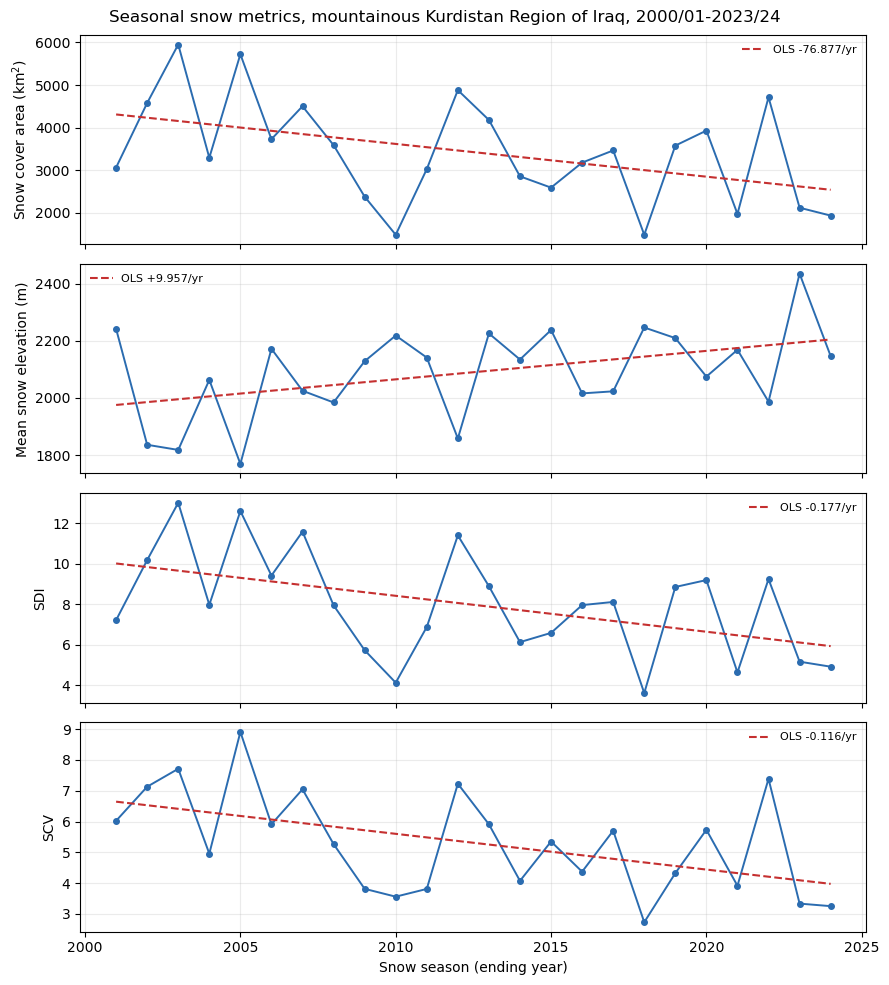

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
for ax, col, lab in zip(axes,
        ["sca_mean", "sle_mean", "sdi_mean", "scv_mean"],
        ["Snow cover area (km$^2$)", "Mean snow elevation (m)", "SDI", "SCV"]):
    d = seasonal[["season", col]].dropna()
    ax.plot(d["season"], d[col], "o-", lw=1.4, ms=4, color="#2b6cb0")
    b, a = np.polyfit(d["season"], d[col], 1)
    ax.plot(d["season"], a + b * d["season"], "--", color="#c53030",
            label=f"OLS {b:+.3f}/yr")
    ax.set_ylabel(lab); ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=.25)
axes[-1].set_xlabel("Snow season (ending year)")
fig.suptitle("Seasonal snow metrics, mountainous Kurdistan Region of Iraq, 2000/01-2023/24")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "fig01_seasonal_snow_metrics.png"), dpi=300)
plt.show()

---
**Next:** `02_climate_predictors_ERA5.ipynb` builds the temperature / precipitation predictors,
`03_circulation_indices.ipynb` builds the teleconnection predictors, and
`04_attribution_analysis.ipynb` performs the attribution.